In [ ]:
from pathlib import Path
import time
import hashlib
import json
import os
import random

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import shap
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

import warnings
warnings.filterwarnings("ignore")
RANDOM_SEED = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [ ]:
DATASET_CANDIDATES = [
    Path("../dataset/fraud.csv"),
    Path("ml/dataset/fraud.csv"),
    Path.cwd() / "dataset" / "fraud.csv",
    Path.cwd().parent / "dataset" / "fraud.csv",
]

DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Place the full fraud dataset at ml/dataset/fraud.csv "
        "before running this notebook. The file is intentionally not committed because of its size."
    )

DATASET_PATH = DATASET_PATH.resolve()


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


DATASET_VERSION = {
    "path": str(DATASET_PATH),
    "file_name": DATASET_PATH.name,
    "file_size_bytes": DATASET_PATH.stat().st_size,
    "last_modified_utc": pd.Timestamp(DATASET_PATH.stat().st_mtime, unit="s", tz="UTC").isoformat(),
    "sha256": sha256_file(DATASET_PATH),
    "sample_size": 50000,
    "sample_random_seed": RANDOM_SEED,
}

print("Dataset version metadata:")
print(json.dumps(DATASET_VERSION, indent=2))

df = pd.read_csv(DATASET_PATH)

df = df.sample(n=DATASET_VERSION["sample_size"], random_state=RANDOM_SEED)

df.head()

## Reproducibility controls

All experiments in this notebook use `RANDOM_SEED = 42` for sampling, train/test splitting, cross-validation shuffling, neural network initialization, Random Forest training, KMeans clustering, PCA initialization, SHAP sampling, and learning-curve shuffling. The dataset version metadata printed above records the local dataset path, file size, modified timestamp, SHA-256 hash, sample size, and sample seed so results can be tied to a specific dataset file.

The notebook is designed to run sequentially from top to bottom after the dataset has been placed at `ml/dataset/fraud.csv`. No cells require manual edits or interactive input.

## Dataset exploration

This section examines the dataset before preprocessing and model training. The goal is to understand data shape, class imbalance, missing values, numeric relationships, and extreme transaction behavior that may affect fraud classification.

In [ ]:
print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

### Descriptive statistics

Descriptive statistics summarize the scale and spread of numeric transaction fields. For fraud detection, quartiles, maximum values, and skewness are especially useful because transaction amounts and account balances are often highly skewed.

In [ ]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

descriptive_stats = df[numeric_columns].describe().T
descriptive_stats["missing_values"] = df[numeric_columns].isnull().sum()
descriptive_stats["skewness"] = df[numeric_columns].skew(numeric_only=True)

descriptive_stats

In [ ]:
distribution_columns = [
    column for column in [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
    ]
    if column in df.columns
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, column in zip(axes, distribution_columns):
    ax.hist(df[column], bins=50)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

for ax in axes[len(distribution_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Class distribution analysis

Fraud datasets are usually highly imbalanced, meaning legitimate transactions greatly outnumber fraudulent transactions. This affects evaluation because a model can achieve high accuracy while still missing fraud cases.

In [ ]:
class_counts = df["isFraud"].value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": ["Not Fraud", "Fraud"],
    "Count": [class_counts.get(0, 0), class_counts.get(1, 0)],
})
class_distribution["Percentage"] = (
    class_distribution["Count"] / class_distribution["Count"].sum() * 100
)

class_distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_distribution["Class"], class_distribution["Count"])
axes[0].set_title("Class Distribution: Fraud vs Non-Fraud")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Transactions")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(class_distribution["Class"], class_distribution["Percentage"])
axes[1].set_title("Class Distribution Percentage")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Percentage of Transactions")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Missing value inspection

Missing values can bias training or cause model failures. The table and chart below report missing counts and percentages for every column before feature selection and encoding.

In [ ]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100,
}).sort_values(by="Missing Count", ascending=False)

missing_summary

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(missing_summary.index, missing_summary["Missing Percentage"])
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Correlation analysis

Correlation analysis identifies linear relationships between numeric features and the fraud label. It also highlights redundancy among balance-related variables. Fraud patterns may be nonlinear, so correlation is exploratory rather than definitive.

In [ ]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Matrix for Numeric Features")

for row in range(len(correlation_matrix.index)):
    for col in range(len(correlation_matrix.columns)):
        plt.text(col, row, f"{correlation_matrix.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

if "isFraud" in correlation_matrix.columns:
    fraud_correlations = correlation_matrix["isFraud"].drop("isFraud").sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )
    display(fraud_correlations.to_frame(name="Correlation with isFraud"))

### Detailed correlation heatmap and high-correlation review

The heatmap below gives a more detailed view of correlations among all numerical features. Correlations near `1.0` indicate variables that increase together, correlations near `-1.0` indicate inverse movement, and values near `0.0` indicate weak linear association. The review also highlights highly correlated feature pairs using an absolute-correlation threshold of `0.70`.

In [ ]:
detailed_correlation_matrix = df[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(12, 10))
heatmap = ax.imshow(detailed_correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(heatmap, ax=ax, label="Correlation coefficient")

ax.set_xticks(range(len(detailed_correlation_matrix.columns)))
ax.set_yticks(range(len(detailed_correlation_matrix.index)))
ax.set_xticklabels(detailed_correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(detailed_correlation_matrix.index)
ax.set_title("Detailed Correlation Heatmap for Numerical Features")

for row in range(len(detailed_correlation_matrix.index)):
    for col in range(len(detailed_correlation_matrix.columns)):
        value = detailed_correlation_matrix.iloc[row, col]
        text_color = "white" if abs(value) >= 0.65 else "black"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
correlation_threshold = 0.70
high_correlation_pairs = []

for i, feature_a in enumerate(detailed_correlation_matrix.columns):
    for j, feature_b in enumerate(detailed_correlation_matrix.columns):
        if j <= i:
            continue

        correlation_value = detailed_correlation_matrix.loc[feature_a, feature_b]
        if abs(correlation_value) >= correlation_threshold:
            high_correlation_pairs.append({
                "Feature A": feature_a,
                "Feature B": feature_b,
                "Correlation": correlation_value,
                "Absolute Correlation": abs(correlation_value),
            })

high_correlation_pairs_df = pd.DataFrame(high_correlation_pairs).sort_values(
    by="Absolute Correlation",
    ascending=False,
)

high_correlation_pairs_df

In [ ]:
if "isFraud" in detailed_correlation_matrix.columns:
    fraud_correlation_df = (
        detailed_correlation_matrix["isFraud"]
        .drop("isFraud")
        .sort_values(key=lambda values: values.abs(), ascending=False)
        .to_frame(name="Correlation with isFraud")
    )

    display(fraud_correlation_df)

    plt.figure(figsize=(10, 5))
    plt.bar(fraud_correlation_df.index, fraud_correlation_df["Correlation with isFraud"])
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Numerical Feature Correlation with Fraud Label")
    plt.xlabel("Feature")
    plt.ylabel("Correlation with isFraud")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Correlation interpretation for fraud detection

Highly correlated numerical variables can influence fraud detection in several ways:

- Balance fields may be strongly correlated because old and new balances are mathematically related before and after a transaction. This can create redundancy in linear models.
- Strongly correlated predictors can make Logistic Regression coefficients harder to interpret because correlated features may share or shift apparent importance.
- Tree-based models such as Random Forest are usually less sensitive to multicollinearity, but correlated features can split feature importance across related variables.
- Neural networks can use correlated inputs, but redundant features may increase training complexity without adding much independent signal.
- A weak linear correlation with `isFraud` does not mean a feature is useless. Fraud patterns may be nonlinear or depend on interactions between transaction amount, type, and balance changes.

For this project, correlated balance variables should be kept initially because the all-feature Random Forest outperformed the reduced SelectKBest model. However, correlation results should be considered when interpreting feature importance and SHAP values, since related balance features may distribute explanatory weight across multiple columns.

### Outlier detection

Outliers are expected in financial transaction data because a small number of transactions can be much larger than typical values. The IQR method flags values below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`. These records are not automatically removed because extreme amounts or balance changes may be meaningful fraud signals.

In [ ]:
outlier_rows = []

for column in distribution_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)

    outlier_rows.append({
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(outlier_mask.sum()),
        "Outlier Percentage": outlier_mask.mean() * 100,
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(by="Outlier Percentage", ascending=False)
outlier_summary

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, column in zip(axes, distribution_columns):
    ax.boxplot(df[column].dropna(), vert=False)
    ax.set_title(f"Outlier Check: {column}")
    ax.set_xlabel(column)
    ax.grid(True, axis="x", alpha=0.3)

for ax in axes[len(distribution_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Dataset exploration interpretation

The exploratory analysis highlights several modeling considerations:

- The target class is highly imbalanced, so model selection should not rely on accuracy alone.
- Transaction amount and balance fields are typically right-skewed, meaning most transactions are small while a smaller number have very large values.
- Missing-value inspection confirms whether imputation is required before modeling. If missing percentages are zero, the notebook can proceed directly to encoding and scaling.
- Correlation analysis gives an initial view of linear relationships, but fraud patterns may be nonlinear; this supports the use of tree-based models and neural networks later in the notebook.
- IQR outlier detection identifies extreme values, but these records should be handled carefully because unusual amount or balance movement may be predictive of fraud rather than erroneous data.

## Data quality assessment

This section evaluates whether the sampled dataset is suitable for modeling. It checks missing values, duplicate rows, inconsistent transaction records, outliers, and feature distributions. The goal is to document cleaning decisions before the notebook selects modeling columns and trains classifiers.

In [ ]:
quality_initial_rows = len(df)
quality_initial_columns = len(df.columns)

quality_overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate rows",
        "Rows with at least one missing value",
        "Total missing values",
    ],
    "Value": [
        quality_initial_rows,
        quality_initial_columns,
        int(df.duplicated().sum()),
        int(df.isnull().any(axis=1).sum()),
        int(df.isnull().sum().sum()),
    ],
})

quality_overview

### Missing values and duplicates

Missing values can break model training or bias the learned patterns. Duplicate transactions can overweight repeated records and make evaluation look better than it really is. The notebook reports these issues explicitly before deciding whether records should be removed.

In [ ]:
missing_quality_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100,
}).sort_values(by="Missing Count", ascending=False)

duplicate_count = int(df.duplicated().sum())
rows_with_missing = int(df.isnull().any(axis=1).sum())

print("Duplicate rows:", duplicate_count)
print("Rows with missing values:", rows_with_missing)
display(missing_quality_summary)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(missing_quality_summary.index, missing_quality_summary["Missing Percentage"])
axes[0].set_title("Missing Values by Column")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Missing Percentage")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(["Duplicates", "Rows with missing"], [duplicate_count, rows_with_missing])
axes[1].set_title("Row-Level Data Quality Issues")
axes[1].set_ylabel("Row count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Inconsistent record checks

The dataset should obey basic transaction constraints. Negative amounts or negative balances are not expected. The fraud label should be binary. For this dataset, `isFlaggedFraud` is an external rule flag and is checked against `isFraud` to understand whether rule-based flags align with the target.

In [ ]:
inconsistency_checks = []

if "amount" in df.columns:
    inconsistency_checks.append({
        "Check": "Negative transaction amount",
        "Affected Rows": int((df["amount"] < 0).sum()),
    })

for balance_column in ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]:
    if balance_column in df.columns:
        inconsistency_checks.append({
            "Check": f"Negative {balance_column}",
            "Affected Rows": int((df[balance_column] < 0).sum()),
        })

if "isFraud" in df.columns:
    valid_fraud_labels = df["isFraud"].isin([0, 1])
    inconsistency_checks.append({
        "Check": "Non-binary isFraud label",
        "Affected Rows": int((~valid_fraud_labels).sum()),
    })

if "isFlaggedFraud" in df.columns:
    valid_flagged_labels = df["isFlaggedFraud"].isin([0, 1])
    inconsistency_checks.append({
        "Check": "Non-binary isFlaggedFraud label",
        "Affected Rows": int((~valid_flagged_labels).sum()),
    })

if {"isFraud", "isFlaggedFraud"}.issubset(df.columns):
    flag_mismatch = (df["isFlaggedFraud"] == 1) & (df["isFraud"] == 0)
    missed_by_flag = (df["isFlaggedFraud"] == 0) & (df["isFraud"] == 1)
    inconsistency_checks.extend([
        {
            "Check": "Flagged as fraud but target is non-fraud",
            "Affected Rows": int(flag_mismatch.sum()),
        },
        {
            "Check": "Fraud target not flagged by rule",
            "Affected Rows": int(missed_by_flag.sum()),
        },
    ])

inconsistency_summary = pd.DataFrame(inconsistency_checks)
inconsistency_summary

In [ ]:
balance_consistency_rows = []

if {"oldbalanceOrg", "newbalanceOrig", "amount"}.issubset(df.columns):
    origin_delta = df["oldbalanceOrg"] - df["newbalanceOrig"]
    origin_difference = (origin_delta - df["amount"]).abs()
    balance_consistency_rows.append({
        "Check": "Origin balance decrease differs from amount",
        "Median Absolute Difference": origin_difference.median(),
        "Mean Absolute Difference": origin_difference.mean(),
        "Rows With Difference > 0": int((origin_difference > 0).sum()),
    })

if {"oldbalanceDest", "newbalanceDest", "amount"}.issubset(df.columns):
    destination_delta = df["newbalanceDest"] - df["oldbalanceDest"]
    destination_difference = (destination_delta - df["amount"]).abs()
    balance_consistency_rows.append({
        "Check": "Destination balance increase differs from amount",
        "Median Absolute Difference": destination_difference.median(),
        "Mean Absolute Difference": destination_difference.mean(),
        "Rows With Difference > 0": int((destination_difference > 0).sum()),
    })

balance_consistency_summary = pd.DataFrame(balance_consistency_rows)
balance_consistency_summary

### Outliers and feature distributions

Outliers are common in financial data. The IQR method below reports extreme values for key numeric features, while the distribution plots show skewness and scale differences. These records are documented rather than removed automatically because unusual transactions may be important fraud signals.

In [ ]:
quality_distribution_columns = [
    column for column in [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
    ]
    if column in df.columns
]

quality_outlier_rows = []
for column in quality_distribution_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    quality_outlier_rows.append({
        "Feature": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(outlier_mask.sum()),
        "Outlier Percentage": outlier_mask.mean() * 100,
        "Skewness": df[column].skew(),
    })

quality_outlier_summary = pd.DataFrame(quality_outlier_rows).sort_values(
    by="Outlier Percentage",
    ascending=False,
)
quality_outlier_summary

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, column in zip(axes, quality_distribution_columns):
    ax.hist(df[column], bins=50)
    ax.set_title(f"Distribution: {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

for ax in axes[len(quality_distribution_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, column in zip(axes, quality_distribution_columns):
    ax.boxplot(df[column].dropna(), vert=False)
    ax.set_title(f"Outlier Profile: {column}")
    ax.set_xlabel(column)
    ax.grid(True, axis="x", alpha=0.3)

for ax in axes[len(quality_distribution_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Cleaning decisions and dataset impact

The notebook documents data quality issues but keeps cleaning conservative:

- Missing values: rows with missing selected modeling fields are removed later by the production training script. In the notebook sample, missing values are inspected before modeling; if missing counts are zero, no imputation is needed.
- Duplicates: duplicate rows are reported but not automatically removed in the notebook because transaction datasets can contain repeated-looking records that are still separate events. If exact duplicates are confirmed to be data-entry errors, they should be removed before training.
- Inconsistent records: negative amounts, negative balances, and non-binary labels are treated as data quality issues. If present, they should be corrected or excluded before deployment training.
- Balance consistency: differences between amount and balance deltas are documented rather than treated as automatic errors because transaction simulations can include account types or states where balances do not update as expected.
- Outliers: extreme amounts and balances are retained because they may contain fraud signal. Removing them could reduce the model's ability to detect high-risk transactions.

Impact on the dataset: this assessment does not change the sampled dataframe directly. It provides evidence for why the notebook keeps outliers, checks missing values before encoding, excludes high-cardinality identifier columns from modeling, and relies on robust evaluation metrics instead of accuracy alone.

In [7]:
selected_columns = [
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud"
]

df = df[selected_columns]

df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
3737323,CASH_IN,330218.42,20866.00,351084.42,452419.57,122201.15,0
264914,PAYMENT,11647.08,30370.00,18722.92,0.00,0.00,0
85647,CASH_IN,152264.21,106589.00,258853.21,201303.01,49038.80,0
5899326,TRANSFER,1551760.63,0.00,0.00,3198359.45,4750120.08,0
2544263,CASH_IN,78172.30,2921331.58,2999503.88,415821.90,337649.60,0


## Business-oriented fraud insights

This section translates the exploratory analysis into business-oriented fraud insights. The goal is to identify transaction patterns, risky transaction types, geographic limitations, and high-risk behaviors that could inform monitoring rules, analyst review queues, and future feature engineering.

In [ ]:
business_overview = pd.DataFrame({
    "Metric": [
        "Total sampled transactions",
        "Fraud transactions",
        "Non-fraud transactions",
        "Fraud rate (%)",
        "Average transaction amount",
        "Average fraud amount",
        "Average non-fraud amount",
    ],
    "Value": [
        len(df),
        int(df["isFraud"].sum()),
        int((df["isFraud"] == 0).sum()),
        df["isFraud"].mean() * 100,
        df["amount"].mean(),
        df.loc[df["isFraud"] == 1, "amount"].mean(),
        df.loc[df["isFraud"] == 0, "amount"].mean(),
    ],
})

business_overview

### Risk by transaction type

Transaction type is one of the most business-readable signals in the dataset. The table below compares transaction volume, fraud count, fraud rate, and amount statistics by transaction category.

In [ ]:
type_risk_summary = (
    df.groupby("type")
    .agg(
        Transactions=("isFraud", "count"),
        Fraud_Count=("isFraud", "sum"),
        Fraud_Rate=("isFraud", "mean"),
        Average_Amount=("amount", "mean"),
        Median_Amount=("amount", "median"),
        Fraud_Average_Amount=("amount", lambda values: df.loc[values.index, "amount"][df.loc[values.index, "isFraud"] == 1].mean()),
    )
    .reset_index()
)
type_risk_summary["Fraud_Rate_Percentage"] = type_risk_summary["Fraud_Rate"] * 100
type_risk_summary.sort_values(by=["Fraud_Rate", "Fraud_Count"], ascending=False)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_type_risk = type_risk_summary.sort_values(by="Fraud_Rate_Percentage", ascending=False)
axes[0].bar(sorted_type_risk["type"], sorted_type_risk["Fraud_Rate_Percentage"])
axes[0].set_title("Fraud Rate by Transaction Type")
axes[0].set_xlabel("Transaction type")
axes[0].set_ylabel("Fraud rate (%)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

sorted_type_volume = type_risk_summary.sort_values(by="Fraud_Count", ascending=False)
axes[1].bar(sorted_type_volume["type"], sorted_type_volume["Fraud_Count"])
axes[1].set_title("Fraud Count by Transaction Type")
axes[1].set_xlabel("Transaction type")
axes[1].set_ylabel("Fraud transaction count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### High-risk transaction amount patterns

Fraud risk can vary by transaction size. The next table bins transaction amounts into quantile-based bands and compares fraud rates across bands.

In [ ]:
amount_band_df = df.copy()
amount_band_df["amount_band"] = pd.qcut(
    amount_band_df["amount"],
    q=5,
    duplicates="drop",
)

amount_band_summary = (
    amount_band_df.groupby("amount_band", observed=False)
    .agg(
        Transactions=("isFraud", "count"),
        Fraud_Count=("isFraud", "sum"),
        Fraud_Rate=("isFraud", "mean"),
        Min_Amount=("amount", "min"),
        Max_Amount=("amount", "max"),
    )
    .reset_index()
)
amount_band_summary["Fraud_Rate_Percentage"] = amount_band_summary["Fraud_Rate"] * 100
amount_band_summary

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(amount_band_summary["amount_band"].astype(str), amount_band_summary["Fraud_Rate_Percentage"])
plt.title("Fraud Rate by Transaction Amount Band")
plt.xlabel("Amount band")
plt.ylabel("Fraud rate (%)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### High-risk balance movement behaviors

Fraudulent transactions may show suspicious account-balance behavior, such as draining the origin account or moving funds through transfer/cash-out transaction types. These indicators are not final rules by themselves, but they help translate model behavior into business monitoring signals.

In [ ]:
behavior_df = df.copy()
behavior_df["origin_balance_emptied"] = (
    (behavior_df["oldbalanceOrg"] > 0) &
    (behavior_df["newbalanceOrig"] == 0)
)
behavior_df["origin_delta"] = behavior_df["oldbalanceOrg"] - behavior_df["newbalanceOrig"]
behavior_df["destination_delta"] = behavior_df["newbalanceDest"] - behavior_df["oldbalanceDest"]
behavior_df["origin_delta_minus_amount_abs"] = (behavior_df["origin_delta"] - behavior_df["amount"]).abs()
behavior_df["destination_delta_minus_amount_abs"] = (behavior_df["destination_delta"] - behavior_df["amount"]).abs()
behavior_df["high_amount"] = behavior_df["amount"] >= behavior_df["amount"].quantile(0.95)
behavior_df["risky_transfer_or_cashout"] = behavior_df["type"].isin(["TRANSFER", "CASH_OUT"])

behavior_flags = [
    "origin_balance_emptied",
    "high_amount",
    "risky_transfer_or_cashout",
]

behavior_summary_rows = []
for flag in behavior_flags:
    flagged = behavior_df[behavior_df[flag]]
    behavior_summary_rows.append({
        "Behavior": flag,
        "Flagged Transactions": len(flagged),
        "Fraud Count": int(flagged["isFraud"].sum()),
        "Fraud Rate (%)": flagged["isFraud"].mean() * 100 if len(flagged) else 0,
        "Share of All Fraud Captured (%)": flagged["isFraud"].sum() / max(behavior_df["isFraud"].sum(), 1) * 100,
    })

behavior_summary = pd.DataFrame(behavior_summary_rows).sort_values(by="Fraud Rate (%)", ascending=False)
behavior_summary

In [ ]:
behavior_summary.plot(
    x="Behavior",
    y=["Fraud Rate (%)", "Share of All Fraud Captured (%)"],
    kind="bar",
    figsize=(12, 5),
)
plt.title("High-Risk Behavior Indicators")
plt.xlabel("Behavior indicator")
plt.ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Country and geography analysis

The current dataset does not include country, region, IP address, merchant country, or customer location fields. Therefore, the notebook cannot identify suspicious countries from this dataset without adding external geographic data. The check below documents this limitation explicitly.

In [ ]:
country_like_columns = [
    column for column in df.columns
    if any(keyword in column.lower() for keyword in ["country", "region", "geo", "location", "ip"])
]

if country_like_columns:
    country_risk_summary = []
    for column in country_like_columns:
        country_summary = (
            df.groupby(column)
            .agg(
                Transactions=("isFraud", "count"),
                Fraud_Count=("isFraud", "sum"),
                Fraud_Rate=("isFraud", "mean"),
            )
            .reset_index()
            .sort_values(by=["Fraud_Rate", "Fraud_Count"], ascending=False)
        )
        country_summary["Column"] = column
        country_risk_summary.append(country_summary)

    display(pd.concat(country_risk_summary, ignore_index=True).head(20))
else:
    print("No country, region, geography, location, or IP-related columns are available in this dataset.")
    print("Suspicious country analysis requires additional geographic features or an enriched dataset version.")

### Business insight summary

The dataset supports several business-level fraud insights:

- Risk should be monitored by transaction type, especially categories that move money out of an account or into another destination.
- High transaction amounts and origin-account depletion are useful review signals, but they should be combined with model probabilities to avoid excessive false positives.
- Balance movement patterns can help identify suspicious behavior when sender and destination balances change in unusual ways.
- The dataset does not support country-level fraud conclusions because no geographic fields are present. Any claim about suspicious countries would require enrichment with customer, merchant, IP, device, or transaction-location data.
- These insights should inform analyst dashboards and rule design, but final alerting decisions should use the trained model, threshold tuning, Precision-Recall analysis, and false-positive review capacity.

### Selected modeling columns

The following columns are retained for the supervised learning experiments. Identifier columns are excluded because they are high-cardinality fields rather than reusable behavioral features.

In [ ]:
df.head()

### Final missing value check after column selection

After selecting modeling columns, the notebook checks missing values again to confirm that the data passed into encoding and model training is complete.

In [ ]:
df.isnull().sum()

In [9]:
df_encoded = pd.get_dummies(df, columns=["type"], drop_first=False)

df_encoded.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3737323,330218.42,20866.00,351084.42,452419.57,122201.15,0,True,False,False,False,False
264914,11647.08,30370.00,18722.92,0.00,0.00,0,False,False,False,True,False
85647,152264.21,106589.00,258853.21,201303.01,49038.80,0,True,False,False,False,False
5899326,1551760.63,0.00,0.00,3198359.45,4750120.08,0,False,False,False,False,True
2544263,78172.30,2921331.58,2999503.88,415821.90,337649.60,0,True,False,False,False,False


In [10]:
X = df_encoded.drop("isFraud", axis=1)
y = df_encoded["isFraud"]

X.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3737323,330218.42,20866.00,351084.42,452419.57,122201.15,True,False,False,False,False
264914,11647.08,30370.00,18722.92,0.00,0.00,False,False,False,True,False
85647,152264.21,106589.00,258853.21,201303.01,49038.80,True,False,False,False,False
5899326,1551760.63,0.00,0.00,3198359.45,4750120.08,False,False,False,False,True
2544263,78172.30,2921331.58,2999503.88,415821.90,337649.60,True,False,False,False,False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Class imbalance analysis and balancing comparison

Fraud detection datasets are usually highly imbalanced: the non-fraud class dominates, while fraud cases are rare. This section quantifies the imbalance, visualizes the class distribution, and compares model behavior before and after applying balancing strategies.

The comparison uses two representative classifiers:

- Logistic Regression, a linear and interpretable baseline.
- Random Forest, the strongest practical model in the main experiments.

For each classifier, the notebook compares an unbalanced baseline, class weighting, and random undersampling of the majority class.

In [ ]:
imbalance_counts = y.value_counts().sort_index()
imbalance_summary = pd.DataFrame({
    "Class": ["Not Fraud", "Fraud"],
    "Count": [imbalance_counts.get(0, 0), imbalance_counts.get(1, 0)],
})
imbalance_summary["Percentage"] = imbalance_summary["Count"] / imbalance_summary["Count"].sum() * 100
imbalance_ratio = imbalance_summary.loc[imbalance_summary["Class"] == "Not Fraud", "Count"].iloc[0] / max(
    imbalance_summary.loc[imbalance_summary["Class"] == "Fraud", "Count"].iloc[0],
    1,
)

print(f"Class imbalance ratio, non-fraud to fraud: {imbalance_ratio:.2f}:1")
imbalance_summary

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(imbalance_summary["Class"], imbalance_summary["Count"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Transaction Count")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(imbalance_summary["Class"], imbalance_summary["Count"])
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)")
axes[1].set_ylabel("Transaction Count, log scale")
axes[1].grid(axis="y", alpha=0.3)

axes[2].pie(
    imbalance_summary["Count"],
    labels=imbalance_summary["Class"],
    autopct="%1.2f%%",
    startangle=90,
)
axes[2].set_title("Class Proportion")

plt.tight_layout()
plt.show()

### Impact of imbalance

Class imbalance affects model training and evaluation in several ways:

- Models can learn to favor the majority non-fraud class because it dominates the loss function.
- Accuracy may look high even when the model misses fraud cases.
- Precision and recall become more informative than accuracy because they focus on fraud detection quality.
- False negatives are especially costly because they represent fraudulent transactions that the model fails to detect.

Balancing techniques address this problem by increasing the importance of the minority class during training. Class weighting changes the model loss so fraud mistakes are penalized more heavily. Random undersampling trains on all fraud cases and a sampled subset of non-fraud cases to reduce majority-class dominance.

In [ ]:
def evaluate_imbalance_model(model_name, model, X_train_data, y_train_data, X_test_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    predictions = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test_data)[:, 1]
        auc_score = roc_auc_score(y_test_data, probabilities)
    else:
        auc_score = None

    cm = confusion_matrix(y_test_data, predictions, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_data, predictions),
        "Precision": precision_score(y_test_data, predictions, zero_division=0),
        "Recall": recall_score(y_test_data, predictions, zero_division=0),
        "F1-score": f1_score(y_test_data, predictions, zero_division=0),
        "ROC-AUC": auc_score,
        "False Positives": fp,
        "False Negatives": fn,
    }

train_for_resampling = X_train.copy()
train_for_resampling["isFraud"] = y_train.values
fraud_train = train_for_resampling[train_for_resampling["isFraud"] == 1]
non_fraud_train = train_for_resampling[train_for_resampling["isFraud"] == 0]

non_fraud_resampled = non_fraud_train.sample(
    n=len(fraud_train),
    random_state=RANDOM_SEED,
)
balanced_train = pd.concat([fraud_train, non_fraud_resampled], ignore_index=True).sample(
    frac=1,
    random_state=RANDOM_SEED,
)

X_train_resampled = balanced_train.drop("isFraud", axis=1)
y_train_resampled = balanced_train["isFraud"].astype(int)

imbalance_scaler = StandardScaler()
X_train_resampled_scaled = imbalance_scaler.fit_transform(X_train_resampled)
X_test_resampled_scaled = imbalance_scaler.transform(X_test)

balancing_results = []

balancing_results.append(evaluate_imbalance_model(
    "Logistic Regression - unbalanced",
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
))

balancing_results.append(evaluate_imbalance_model(
    "Logistic Regression - class_weight=balanced",
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
))

balancing_results.append(evaluate_imbalance_model(
    "Logistic Regression - random undersampling",
    LogisticRegression(max_iter=1000),
    X_train_resampled_scaled,
    y_train_resampled,
    X_test_resampled_scaled,
    y_test,
))

balancing_results.append(evaluate_imbalance_model(
    "Random Forest - unbalanced",
    RandomForestClassifier(n_estimators=100, max_depth=20, random_state=RANDOM_SEED, n_jobs=-1),
    X_train,
    y_train,
    X_test,
    y_test,
))

balancing_results.append(evaluate_imbalance_model(
    "Random Forest - class_weight=balanced",
    RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    X_train,
    y_train,
    X_test,
    y_test,
))

balancing_results.append(evaluate_imbalance_model(
    "Random Forest - random undersampling",
    RandomForestClassifier(n_estimators=100, max_depth=20, random_state=RANDOM_SEED, n_jobs=-1),
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
))

balancing_results_df = pd.DataFrame(balancing_results)
balancing_results_df.sort_values(by="F1-score", ascending=False)

In [ ]:
metrics_to_plot = ["Precision", "Recall", "F1-score"]
plot_df = balancing_results_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(14, 6))
ax.set_title("Effect of Balancing Techniques on Fraud Classification Metrics")
ax.set_xlabel("Model and balancing strategy")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Balancing comparison interpretation

The unbalanced models are expected to favor the majority class and may miss fraud cases, which lowers recall even when accuracy appears strong. Class weighting usually increases fraud sensitivity by penalizing minority-class mistakes more heavily. Random undersampling can also improve recall because the model sees a balanced training set, but it discards many legitimate examples, which may increase false positives or reduce generalization.

For fraud detection, the best balancing strategy is not necessarily the one with the highest accuracy. The preferred model should improve recall and F1-score while keeping false positives manageable. If class weighting provides similar recall to undersampling with fewer false positives, it is often preferable because it keeps all available training data. If undersampling substantially improves recall, it may be useful for experimentation, but should be validated carefully with cross-validation and confusion matrices before deployment.

In [ ]:
confusion_matrices = {}


def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_proba)
    else:
        roc_auc = None
    
    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, zero_division=0)
    recall = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)
    cm = confusion_matrix(y_test_data, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    confusion_matrices[model_name] = cm
    
    print("Model:", model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred, zero_division=0))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
    }


## Hyperparameter tuning setup

The following classifiers are tuned with `GridSearchCV` using 3-fold cross-validation and F1-score as the optimization metric. F1-score is used because the dataset is highly imbalanced and fraud detection needs a balance between precision and recall.

### Tested grids and selected values

| Classifier | Tested hyperparameter grid | Final selected values |
|---|---|---|
| Logistic Regression | `C: [0.1, 1, 10]`; `solver: ["liblinear"]` | `C=10`; `solver="liblinear"` |
| KNN | `n_neighbors: [3, 5, 7]`; `weights: ["uniform", "distance"]` | `n_neighbors=3`; `weights="distance"` |
| Decision Tree | `max_depth: [5, 10, 15, None]`; `min_samples_split: [2, 5, 10]`; `criterion: ["gini", "entropy"]` | `max_depth=15`; `min_samples_split=2`; `criterion="entropy"` |
| Random Forest | `n_estimators: [50, 100]`; `max_depth: [10, 20, None]`; `min_samples_split: [2, 5]` | `n_estimators=100`; `max_depth=20`; `min_samples_split=5` |
| Neural Network (MLP) | `hidden_layer_sizes: [(32,), (64,), (64, 32)]`; `activation: ["relu", "tanh"]`; `learning_rate_init: [0.001, 0.01]` | `hidden_layer_sizes=(32,)`; `activation="tanh"`; `learning_rate_init=0.01` |

### Best-parameter summary

| Model | Best parameters |
|---|---|
| Logistic Regression | `{"C": 10, "solver": "liblinear"}` |
| KNN | `{"n_neighbors": 3, "weights": "distance"}` |
| Decision Tree | `{"criterion": "entropy", "max_depth": 15, "min_samples_split": 2}` |
| Random Forest | `{"max_depth": 20, "min_samples_split": 5, "n_estimators": 100}` |
| Neural Network (MLP) | `{"activation": "tanh", "hidden_layer_sizes": (32,), "learning_rate_init": 0.01}` |


In [14]:
log_reg_params = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear"]
}

log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    log_reg_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

log_reg_grid.fit(X_train_scaled, y_train)

best_log_reg = log_reg_grid.best_estimator_

print("Best Logistic Regression parameters:")
print(log_reg_grid.best_params_)

Best Logistic Regression parameters:
{'C': 10, 'solver': 'liblinear'}


In [15]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        best_log_reg,
        X_test_scaled,
        y_test
    )
)

Model: Logistic Regression
Accuracy: 0.9467
Precision: 0.023853211009174313
Recall: 0.9285714285714286
F1-score: 0.046511627906976744
ROC-AUC: 0.9245372092357873

Confusion Matrix:
[[9454  532]
 [   1   13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      9986
           1       0.02      0.93      0.05        14

    accuracy                           0.95     10000
   macro avg       0.51      0.94      0.51     10000
weighted avg       1.00      0.95      0.97     10000



In [16]:
knn_params = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_

print("Best KNN parameters:")
print(knn_grid.best_params_)

Best KNN parameters:
{'n_neighbors': 3, 'weights': 'distance'}


In [17]:
results.append(
    evaluate_model(
        "KNN",
        best_knn,
        X_test_scaled,
        y_test
    )
)

Model: KNN
Accuracy: 0.9994
Precision: 0.9
Recall: 0.6428571428571429
F1-score: 0.75
ROC-AUC: 0.8569497296214702

Confusion Matrix:
[[9985    1]
 [   5    9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       0.90      0.64      0.75        14

    accuracy                           1.00     10000
   macro avg       0.95      0.82      0.87     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
tree_params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
    tree_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

best_tree = tree_grid.best_estimator_

print("Best Decision Tree parameters:")
print(tree_grid.best_params_)

In [19]:
results.append(
    evaluate_model(
        "Decision Tree",
        best_tree,
        X_test,
        y_test
    )
)

Model: Decision Tree
Accuracy: 0.9993
Precision: 0.7692307692307693
Recall: 0.7142857142857143
F1-score: 0.7407407407407407
ROC-AUC: 0.856992646848445

Confusion Matrix:
[[9983    3]
 [   4   10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       0.77      0.71      0.74        14

    accuracy                           1.00     10000
   macro avg       0.88      0.86      0.87     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
rf_params = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
    rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

In [21]:
results.append(
    evaluate_model(
        "Random Forest",
        best_rf,
        X_test,
        y_test
    )
)

Model: Random Forest
Accuracy: 0.9997
Precision: 1.0
Recall: 0.7857142857142857
F1-score: 0.88
ROC-AUC: 0.9269548796887072

Confusion Matrix:
[[9986    0]
 [   3   11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       1.00      0.79      0.88        14

    accuracy                           1.00     10000
   macro avg       1.00      0.89      0.94     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
mlp_params = {
    "hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32)
    ],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=RANDOM_SEED),
    mlp_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

mlp_grid.fit(X_train_scaled, y_train)

best_mlp = mlp_grid.best_estimator_

print("Best Neural Network parameters:")
print(mlp_grid.best_params_)

In [23]:
results.append(
    evaluate_model(
        "Neural Network MLP",
        best_mlp,
        X_test_scaled,
        y_test
    )
)

Model: Neural Network MLP
Accuracy: 0.9996
Precision: 1.0
Recall: 0.7142857142857143
F1-score: 0.8333333333333334
ROC-AUC: 0.9720394266258476

Confusion Matrix:
[[9986    0]
 [   4   10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9986
           1       1.00      0.71      0.83        14

    accuracy                           1.00     10000
   macro avg       1.00      0.86      0.92     10000
weighted avg       1.00      1.00      1.00     10000



In [24]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9467,0.023853,0.928571,0.046512,0.924537
1,KNN,0.9994,0.900000,0.642857,0.750000,0.856950
2,Decision Tree,0.9993,0.769231,0.714286,0.740741,0.856993
3,Random Forest,0.9997,1.000000,0.785714,0.880000,0.926955
4,Neural Network MLP,0.9996,1.000000,0.714286,0.833333,0.972039


## Saving trained experiment artifacts

The tuned classifiers and experiment metadata are saved as local artifacts so trained models can be reused without rerunning the full notebook. These generated files are ignored by Git because model artifacts can be large and environment-specific.

In [ ]:
NOTEBOOK_MODEL_DIR = Path("../models/notebook_experiments")
if not NOTEBOOK_MODEL_DIR.parent.exists():
    NOTEBOOK_MODEL_DIR = Path("ml/models/notebook_experiments")

NOTEBOOK_MODEL_DIR.mkdir(parents=True, exist_ok=True)

trained_models = {
    "logistic_regression": best_log_reg,
    "knn": best_knn,
    "decision_tree": best_tree,
    "random_forest": best_rf,
    "neural_network_mlp": best_mlp,
}

for model_name, model in trained_models.items():
    joblib.dump(model, NOTEBOOK_MODEL_DIR / f"{model_name}.joblib")

joblib.dump(scaler, NOTEBOOK_MODEL_DIR / "standard_scaler.joblib")
joblib.dump(list(X.columns), NOTEBOOK_MODEL_DIR / "feature_columns.joblib")

experiment_metadata = {
    "random_seed": RANDOM_SEED,
    "dataset_version": DATASET_VERSION,
    "sklearn_version": sklearn.__version__,
    "model_names": list(trained_models.keys()),
    "feature_columns": list(X.columns),
    "target_column": "isFraud",
    "results": results_df.to_dict(orient="records"),
}

with (NOTEBOOK_MODEL_DIR / "experiment_metadata.json").open("w", encoding="utf-8") as metadata_file:
    json.dump(experiment_metadata, metadata_file, indent=2)

print(f"Saved notebook experiment artifacts to: {NOTEBOOK_MODEL_DIR.resolve()}")

## Classifier comparison discussion

The table above compares the classifiers using accuracy, precision, recall, F1-score, and ROC-AUC. Because fraud is rare, the most useful comparison emphasizes recall, precision, F1-score, confusion matrix behavior, and operational suitability rather than accuracy alone.

| Model | Strengths | Weaknesses | Computational complexity and training time | Interpretability | Suitability for fraud detection |
|---|---|---|---|---|---|
| Logistic Regression | Fast baseline; produces probabilities; works well when relationships are approximately linear; class weighting helps with imbalance. | Limited ability to model nonlinear fraud patterns; in the recorded run it produced many false positives despite high recall. | Low computational complexity and usually the shortest training time. It scales well to larger datasets. | High. Coefficients can be inspected to understand feature direction and relative contribution. | Useful as a transparent baseline or high-recall screening model, but weak precision makes it risky as a standalone fraud alert model without threshold tuning. |
| KNN | Simple non-parametric method; can capture local similarity patterns after scaling. | Prediction can be slow because each new transaction is compared with stored training examples; sensitive to scaling, noisy features, and sparse fraud examples. | Low training cost, but higher inference cost. Runtime grows with training set size and feature count. | Moderate to low. Individual predictions can be linked to neighbors, but there is no compact global model. | Less suitable for production fraud detection at scale, though useful as a comparison model. |
| Decision Tree | Captures nonlinear rules; fast inference; naturally models feature interactions; easy to explain conceptually. | High variance; can overfit transaction patterns specific to one split or fold. | Low to moderate training time and very fast inference. Complexity increases with tree depth. | High. Decision paths can be converted into rule-like explanations. | Useful for interpretable rule discovery, but less stable than Random Forest and weaker as a final model. |
| Random Forest | Strong F1-score in the main comparison; captures nonlinear relationships; reduces variance by averaging many trees; supports feature importance. | Less transparent than a single tree; larger model; probability thresholds may still need calibration. | Moderate training time because many trees are fitted; inference is practical but slower than Logistic Regression or one Decision Tree. | Moderate. Global feature importance and SHAP help explain behavior, but ensemble decisions are less direct than one tree. | Strong practical choice because it balances precision, recall, stability, nonlinear modeling, and explainability. |
| Neural Network MLP | Strong ROC-AUC in the recorded results; can model complex nonlinear interactions; deeper architectures can improve recall. | Less interpretable; requires scaling; sensitive to architecture, optimization, and class imbalance. | Moderate to high training time compared with simpler models. Complexity increases with hidden layers, units, and iterations. | Low without external explainability methods. Requires SHAP or other techniques for reporting. | Promising for probability ranking, but harder to justify operationally than Random Forest without more tuning and calibration. |

Overall, Random Forest is the most balanced model for this project because it combines strong F1-score, low false-positive behavior in the recorded split, nonlinear modeling capacity, and usable interpretability through feature importance and SHAP. Neural Network MLP separates fraud and non-fraud well by ROC-AUC, but its lower interpretability and higher tuning burden make it harder to deploy as the primary model without additional validation. Logistic Regression remains valuable as a transparent baseline, while KNN and Decision Tree are useful comparison models but less suitable as final production choices.

## Confusion matrix comparison

The confusion matrix shows how each classifier separates legitimate and fraudulent transactions. In this binary classification task, false positives are legitimate transactions incorrectly flagged as fraud, while false negatives are fraudulent transactions missed by the model. False negatives are especially important because they represent fraud that would pass through the system.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Fraud", "Fraud"],
    )
    display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(model_name)

for ax in axes[len(confusion_matrices):]:
    ax.axis("off")

plt.suptitle("Confusion Matrix Comparison by Classifier", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
confusion_interpretation = []

for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    confusion_interpretation.append({
        "Model": model_name,
        "False Positives": fp,
        "False Negatives": fn,
        "Interpretation": (
            f"{fp} legitimate transactions were incorrectly flagged as fraud; "
            f"{fn} fraudulent transactions were missed."
        ),
    })

pd.DataFrame(confusion_interpretation)

### Confusion matrix interpretation

Using the recorded notebook run:

| Model | False positives | False negatives | Interpretation |
|---|---:|---:|---|
| Logistic Regression | 532 | 1 | Catches almost every fraud case, but incorrectly flags many legitimate transactions. This explains the high recall and very low precision. |
| KNN | 1 | 5 | Keeps false alerts low, but misses five fraud cases, so recall is lower than Logistic Regression. |
| Decision Tree | 3 | 4 | Produces a small number of false alerts and misses four fraud cases, giving balanced but weaker performance than Random Forest. |
| Random Forest | 0 | 3 | Produces no false positives in the recorded run and misses only three fraud cases, giving the best F1-score among the main classifiers. |
| Neural Network MLP | 0 | 4 | Also avoids false positives, but misses one more fraud case than Random Forest in the main comparison. Its ROC-AUC remains strong, suggesting useful probability ranking. |

For fraud detection, false negatives are usually the more serious operational risk because they allow fraudulent transactions to pass through. False positives still matter because they can create unnecessary reviews or block legitimate customers.

## Training and prediction time comparison

Predictive performance is only one part of model selection. Fraud detection systems also need models that can be trained, updated, and served within practical time limits. This section measures training time and prediction time for all classification models using the same train/test split.

The benchmark clones the tuned estimators before fitting so the previously trained models remain unchanged. For models that require scaling, the benchmark wraps the estimator in a `StandardScaler` pipeline.

In [ ]:
timing_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), clone(best_log_reg)),
    "KNN": make_pipeline(StandardScaler(), clone(best_knn)),
    "Decision Tree": clone(best_tree),
    "Random Forest": clone(best_rf),
    "Neural Network MLP": make_pipeline(StandardScaler(), clone(best_mlp)),
}

timing_results = []

for model_name, model in timing_models.items():
    train_start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - train_start

    predict_start = time.perf_counter()
    predictions = model.predict(X_test)
    prediction_time = time.perf_counter() - predict_start

    if hasattr(model, "predict_proba"):
        probability_start = time.perf_counter()
        probabilities = model.predict_proba(X_test)[:, 1]
        probability_time = time.perf_counter() - probability_start
        auc_score = roc_auc_score(y_test, probabilities)
    else:
        probability_time = None
        auc_score = None

    timing_results.append({
        "Model": model_name,
        "Training Time (s)": train_time,
        "Prediction Time (s)": prediction_time,
        "Probability Prediction Time (s)": probability_time,
        "Prediction Time per 1,000 Rows (ms)": prediction_time / len(X_test) * 1000 * 1000,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": auc_score,
    })

timing_results_df = pd.DataFrame(timing_results).sort_values(by="Training Time (s)")
timing_results_df

In [ ]:
performance_cost_summary = timing_results_df[[
    "Model",
    "Training Time (s)",
    "Prediction Time (s)",
    "Prediction Time per 1,000 Rows (ms)",
    "F1-score",
    "ROC-AUC",
]].sort_values(by="F1-score", ascending=False)

performance_cost_summary

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(timing_results_df["Model"], timing_results_df["Training Time (s)"])
axes[0].set_title("Training Time by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

prediction_sorted = timing_results_df.sort_values(by="Prediction Time per 1,000 Rows (ms)")
axes[1].bar(prediction_sorted["Model"], prediction_sorted["Prediction Time per 1,000 Rows (ms)"])
axes[1].set_title("Prediction Time per 1,000 Rows")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Milliseconds")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(
    timing_results_df["Training Time (s)"],
    timing_results_df["F1-score"],
    s=100,
)

for _, row in timing_results_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Training Time (s)"], row["F1-score"]),
        textcoords="offset points",
        xytext=(6, 6),
    )

plt.title("Performance vs Training Cost")
plt.xlabel("Training Time (s)")
plt.ylabel("F1-score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Computational cost interpretation

The timing results should be interpreted together with fraud-detection metrics:

- Logistic Regression is usually the fastest model to train and predict. It is a strong baseline when transparency and speed are priorities, but its fraud precision may be weak.
- KNN has little traditional training cost, but prediction can be slower because each new transaction must be compared with stored training examples. This can be a disadvantage in high-volume fraud screening.
- Decision Tree generally trains and predicts quickly while remaining interpretable, but it can overfit and may be less stable than ensemble methods.
- Random Forest requires more training time than a single tree because many trees are fitted, but it offers a strong tradeoff between F1-score, robustness, and explainability.
- Neural Network MLP can be more expensive to train because optimization runs iteratively. It may provide strong probability ranking, but the extra cost and lower interpretability must be justified.

For this project, Random Forest remains a practical choice if its training and prediction times are acceptable for the expected transaction volume. If real-time latency is the dominant constraint, Logistic Regression or Decision Tree may be easier to serve, but their lower fraud-detection quality must be considered. If maximizing ranking performance is more important than interpretability or training cost, the Neural Network MLP is a reasonable candidate for further tuning.

## ROC curve analysis

ROC curves compare how well each classifier separates fraud from non-fraud across all possible probability thresholds. The true positive rate measures fraud detection sensitivity, while the false positive rate measures how often legitimate transactions are incorrectly flagged. A larger area under the curve (AUC) means the model ranks fraudulent transactions above legitimate transactions more effectively.

In [ ]:
roc_models = {
    "Logistic Regression": (best_log_reg, X_test_scaled),
    "KNN": (best_knn, X_test_scaled),
    "Decision Tree": (best_tree, X_test),
    "Random Forest": (best_rf, X_test),
    "Neural Network MLP": (best_mlp, X_test_scaled),
}

roc_results = []

plt.figure(figsize=(10, 7))

for model_name, (model, X_test_data) in roc_models.items():
    y_proba = model.predict_proba(X_test_data)[:, 1]
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    roc_results.append({
        "Model": model_name,
        "AUC": auc_score,
    })

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.4f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.title("ROC Curves by Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

roc_results_df = pd.DataFrame(roc_results).sort_values(by="AUC", ascending=False)
roc_results_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(roc_results_df["Model"], roc_results_df["AUC"])
plt.title("AUC Score Comparison by Classifier")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0.0, 1.0)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### ROC-AUC interpretation

Using the recorded notebook results, the Neural Network MLP has the strongest separation between fraud and non-fraud transactions with an ROC-AUC of `0.9720`. This indicates that its predicted probabilities rank fraudulent transactions above legitimate transactions most effectively across thresholds.

Random Forest (`0.9270`) and Logistic Regression (`0.9245`) are close behind by ROC-AUC, but they behave differently in the confusion matrix: Random Forest keeps false positives low, while Logistic Regression catches nearly all fraud but incorrectly flags many legitimate transactions. KNN (`0.8569`) and Decision Tree (`0.8570`) show weaker ranking performance.

For threshold-independent separation, Neural Network MLP is the strongest model. For practical fraud detection, ROC-AUC should still be interpreted together with precision, recall, F1-score, and false-positive/false-negative counts because the deployed decision threshold controls operational risk.

## Precision-Recall curve analysis

Precision-Recall curves show the tradeoff between precision and recall as the classification threshold changes. This is especially important for fraud detection because the fraud class is rare and the main modeling goal is to detect minority-class fraud without creating too many false alerts.

In [ ]:
pr_models = {
    "Logistic Regression": (best_log_reg, X_test_scaled),
    "KNN": (best_knn, X_test_scaled),
    "Decision Tree": (best_tree, X_test),
    "Random Forest": (best_rf, X_test),
    "Neural Network MLP": (best_mlp, X_test_scaled),
}

pr_results = []
positive_rate = y_test.mean()

plt.figure(figsize=(10, 7))

for model_name, (model, X_test_data) in pr_models.items():
    y_proba = model.predict_proba(X_test_data)[:, 1]
    precision_values, recall_values, thresholds = precision_recall_curve(y_test, y_proba)
    average_precision = average_precision_score(y_test, y_proba)

    pr_results.append({
        "Model": model_name,
        "Average Precision": average_precision,
    })

    plt.plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=f"{model_name} (AP = {average_precision:.4f})",
    )

plt.axhline(positive_rate, linestyle="--", color="gray", label=f"Fraud baseline = {positive_rate:.4f}")
plt.title("Precision-Recall Curves by Classifier")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

pr_results_df = pd.DataFrame(pr_results).sort_values(by="Average Precision", ascending=False)
pr_results_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(pr_results_df["Model"], pr_results_df["Average Precision"])
plt.title("Average Precision Comparison by Classifier")
plt.xlabel("Model")
plt.ylabel("Average Precision")
plt.ylim(0.0, 1.0)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Precision-Recall interpretation

Precision-Recall analysis is particularly important for this project because the fraud class is heavily imbalanced. In imbalanced datasets, ROC-AUC can sometimes look strong even when precision is poor, because the false-positive rate is diluted by the very large number of legitimate transactions. Precision directly answers a more operational question: when the model flags a transaction as fraud, how often is it correct?

A strong fraud detection model should maintain high precision while recall increases. High recall alone is not enough if it creates too many false alerts, and high precision alone is not enough if the model misses most fraud. Average Precision summarizes the full Precision-Recall curve and is therefore useful for comparing classifiers on the minority fraud class.

For final model selection, Precision-Recall results should be interpreted together with threshold tuning, confusion matrices, and cross-validation stability. A model with strong Average Precision gives more flexibility to choose an operating threshold that balances fraud capture against review workload.

## Probability threshold tuning

Most classifiers use a default probability threshold of `0.5`: transactions with predicted fraud probability at or above `0.5` are classified as fraud. In fraud detection, this threshold should be tuned because the operational cost of false negatives and false positives is not equal.

Lower thresholds usually increase recall because more fraud cases are flagged, but they can reduce precision by increasing false positives. Higher thresholds usually increase precision, but they can miss more fraud cases. The analysis below compares precision, recall, and F1-score across thresholds and selects the threshold with the best F1-score.

In [ ]:
threshold_models = {
    "Logistic Regression": (best_log_reg, X_test_scaled),
    "KNN": (best_knn, X_test_scaled),
    "Decision Tree": (best_tree, X_test),
    "Random Forest": (best_rf, X_test),
    "Neural Network MLP": (best_mlp, X_test_scaled),
}

threshold_values = np.round(np.arange(0.05, 0.96, 0.05), 2)
threshold_results = []

for model_name, (model, X_test_data) in threshold_models.items():
    probabilities = model.predict_proba(X_test_data)[:, 1]

    for threshold in threshold_values:
        predictions = (probabilities >= threshold).astype(int)
        cm = confusion_matrix(y_test, predictions, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision_score(y_test, predictions, zero_division=0),
            "Recall": recall_score(y_test, predictions, zero_division=0),
            "F1-score": f1_score(y_test, predictions, zero_division=0),
            "False Positives": fp,
            "False Negatives": fn,
        })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df.head()

In [ ]:
best_thresholds_df = (
    threshold_results_df.sort_values(
        by=["Model", "F1-score", "Recall"],
        ascending=[True, False, False],
    )
    .groupby("Model", as_index=False)
    .first()
    .sort_values(by="F1-score", ascending=False)
)

best_thresholds_df

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.ravel()

for ax, model_name in zip(axes, threshold_models.keys()):
    model_thresholds = threshold_results_df[threshold_results_df["Model"] == model_name]
    ax.plot(model_thresholds["Threshold"], model_thresholds["Precision"], marker="o", label="Precision")
    ax.plot(model_thresholds["Threshold"], model_thresholds["Recall"], marker="s", label="Recall")
    ax.plot(model_thresholds["Threshold"], model_thresholds["F1-score"], marker="^", label="F1-score")
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Default 0.5")

    best_threshold = best_thresholds_df.loc[
        best_thresholds_df["Model"] == model_name,
        "Threshold",
    ].iloc[0]
    ax.axvline(best_threshold, color="red", linestyle=":", linewidth=1.5, label="Best F1 threshold")
    ax.set_title(model_name)
    ax.set_xlabel("Probability threshold")
    ax.set_ylabel("Score")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(threshold_models):]:
    ax.axis("off")

plt.suptitle("Precision, Recall, and F1-score Across Probability Thresholds", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
best_overall_threshold = best_thresholds_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("Best threshold by F1-score:")
print(best_overall_threshold)

plt.figure(figsize=(10, 5))
plt.bar(best_thresholds_df["Model"], best_thresholds_df["F1-score"])
plt.title("Best F1-score After Threshold Tuning")
plt.xlabel("Model")
plt.ylabel("Best F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold tuning interpretation

The default `0.5` threshold is only a starting point. In fraud detection, lowering the threshold can catch more fraudulent transactions, but it usually increases false positives. Raising the threshold can reduce false alerts, but it may allow more fraud to pass undetected.

The best threshold in the table is selected by F1-score because F1 balances precision and recall. This is appropriate when both missed fraud and unnecessary alerts matter. If the business goal prioritizes catching as much fraud as possible, a lower threshold with higher recall may be preferred even if F1-score is slightly lower. If manual review capacity is limited, a higher threshold with stronger precision may be more practical.

For this project, the optimal fraud-detection threshold should be selected from the model with the strongest validation behavior and the best tradeoff between false positives and false negatives. The threshold table should be interpreted together with the confusion matrix, cross-validation stability, and ROC-AUC results before choosing a production operating point.

## Error analysis of misclassified transactions

This section investigates the transactions that the selected practical model, Random Forest, classified incorrectly. Error analysis helps identify whether mistakes are concentrated in specific transaction types, transaction amounts, balance patterns, or probability ranges.

The analysis separates test-set transactions into:

- True negatives: legitimate transactions correctly classified as non-fraud.
- False positives: legitimate transactions incorrectly flagged as fraud.
- False negatives: fraudulent transactions missed by the model.
- True positives: fraudulent transactions correctly detected.

In [ ]:
rf_error_predictions = best_rf.predict(X_test)
rf_error_probabilities = best_rf.predict_proba(X_test)[:, 1]

error_analysis_df = df.loc[X_test.index].copy()
error_analysis_df["actual_isFraud"] = y_test.values
error_analysis_df["predicted_isFraud"] = rf_error_predictions
error_analysis_df["predicted_fraud_probability"] = rf_error_probabilities

conditions = [
    (error_analysis_df["actual_isFraud"] == 0) & (error_analysis_df["predicted_isFraud"] == 0),
    (error_analysis_df["actual_isFraud"] == 0) & (error_analysis_df["predicted_isFraud"] == 1),
    (error_analysis_df["actual_isFraud"] == 1) & (error_analysis_df["predicted_isFraud"] == 0),
    (error_analysis_df["actual_isFraud"] == 1) & (error_analysis_df["predicted_isFraud"] == 1),
]
choices = ["True Negative", "False Positive", "False Negative", "True Positive"]
error_analysis_df["prediction_outcome"] = np.select(conditions, choices, default="Unknown")

error_counts = error_analysis_df["prediction_outcome"].value_counts().reindex(choices, fill_value=0)
error_counts.to_frame(name="Count")

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(error_counts.index, error_counts.values)
plt.title("Random Forest Prediction Outcomes")
plt.xlabel("Prediction outcome")
plt.ylabel("Transaction count")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
analysis_numeric_columns = [
    column for column in [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "predicted_fraud_probability",
    ]
    if column in error_analysis_df.columns
]

outcome_summary = error_analysis_df.groupby("prediction_outcome")[analysis_numeric_columns].agg([
    "count",
    "mean",
    "median",
    "min",
    "max",
])

outcome_summary

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_analysis_df.boxplot(
    column="amount",
    by="prediction_outcome",
    ax=axes[0],
    rot=20,
)
axes[0].set_title("Transaction Amount by Prediction Outcome")
axes[0].set_xlabel("Prediction outcome")
axes[0].set_ylabel("Amount")
axes[0].grid(axis="y", alpha=0.3)

error_analysis_df.boxplot(
    column="predicted_fraud_probability",
    by="prediction_outcome",
    ax=axes[1],
    rot=20,
)
axes[1].set_title("Predicted Fraud Probability by Prediction Outcome")
axes[1].set_xlabel("Prediction outcome")
axes[1].set_ylabel("Predicted fraud probability")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
type_outcome_counts = pd.crosstab(
    error_analysis_df["type"],
    error_analysis_df["prediction_outcome"],
).reindex(columns=choices, fill_value=0)

type_outcome_rates = type_outcome_counts.div(type_outcome_counts.sum(axis=1), axis=0).fillna(0)

display(type_outcome_counts)
display(type_outcome_rates)

In [ ]:
type_outcome_counts.plot(kind="bar", figsize=(12, 6))
plt.title("Prediction Outcomes by Transaction Type")
plt.xlabel("Transaction type")
plt.ylabel("Transaction count")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
false_positive_examples = error_analysis_df[
    error_analysis_df["prediction_outcome"] == "False Positive"
].sort_values(by="predicted_fraud_probability", ascending=False)

false_negative_examples = error_analysis_df[
    error_analysis_df["prediction_outcome"] == "False Negative"
].sort_values(by="predicted_fraud_probability", ascending=False)

print("False positive examples:", len(false_positive_examples))
display(false_positive_examples.head(10))

print("False negative examples:", len(false_negative_examples))
display(false_negative_examples.head(10))

In [ ]:
misclassified_transactions = error_analysis_df[
    error_analysis_df["prediction_outcome"].isin(["False Positive", "False Negative"])
]
correctly_classified_transactions = error_analysis_df[
    error_analysis_df["prediction_outcome"].isin(["True Negative", "True Positive"])
]

comparison_rows = []
for column in analysis_numeric_columns:
    comparison_rows.append({
        "Feature": column,
        "Correct Mean": correctly_classified_transactions[column].mean(),
        "Misclassified Mean": misclassified_transactions[column].mean(),
        "Correct Median": correctly_classified_transactions[column].median(),
        "Misclassified Median": misclassified_transactions[column].median(),
    })

misclassification_comparison_df = pd.DataFrame(comparison_rows)
misclassification_comparison_df

### Error analysis interpretation

False positives and false negatives usually occur near ambiguous regions of the feature space:

- False positives can occur when legitimate transactions resemble fraud patterns, such as high transaction amounts, transfer-like behavior, or unusual balance changes.
- False negatives can occur when fraudulent transactions look similar to normal customer behavior, have lower predicted fraud probability, or do not show the strongest balance-change patterns learned by the Random Forest.
- If false negatives are concentrated in specific transaction types, the model may need additional features or a lower decision threshold for those transaction categories.
- If false positives have high predicted fraud probabilities, the model is confidently reacting to patterns that resemble fraud; this may require better features to distinguish unusual but legitimate activity from actual fraud.
- If false negatives have probabilities just below the default threshold, threshold tuning may reduce missed fraud at the cost of more false alerts.

This analysis should be read together with the threshold tuning and Precision-Recall sections. In fraud detection, not every model mistake has the same operational cost: false negatives represent fraud that passes undetected, while false positives increase manual review workload and can inconvenience legitimate users. Future improvements could include transaction-history features, customer-level aggregates, calibrated probabilities, cost-sensitive thresholds, and separate review rules for transaction types with higher error rates.

## K-fold cross-validation

A single train/test split can make model results depend on which rare fraud records happen to land in the test set. Stratified k-fold cross-validation gives a more stable estimate by training and validating each classifier across multiple folds while preserving the fraud/non-fraud class balance as much as possible.

The table below reports average accuracy, precision, recall, and F1-score across folds. Standard deviations are included to show model stability: smaller standard deviation means performance is more consistent across folds.

In [ ]:
cv_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), best_log_reg),
    "KNN": make_pipeline(StandardScaler(), best_knn),
    "Decision Tree": best_tree,
    "Random Forest": best_rf,
    "Neural Network MLP": make_pipeline(StandardScaler(), best_mlp),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

cv_results = []

for model_name, model in cv_models.items():
    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1-score Mean": scores["test_f1"].mean(),
        "F1-score Std": scores["test_f1"].std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="F1-score Mean",
    ascending=False,
)

cv_results_df

In [ ]:
stability_summary = cv_results_df[[
    "Model",
    "Accuracy Std",
    "Precision Std",
    "Recall Std",
    "F1-score Std",
]].copy()

stability_summary["Overall Stability"] = stability_summary["F1-score Std"].apply(
    lambda value: "High" if value <= 0.05 else "Moderate" if value <= 0.15 else "Low"
)

stability_summary.sort_values(by="F1-score Std")

### Cross-validation stability discussion

Use the cross-validation comparison table to evaluate both average performance and fold-to-fold consistency:

- Models with high average F1-score and low F1-score standard deviation are the most stable choices because they perform well across different fraud/non-fraud splits.
- Logistic Regression may show stable recall but weak precision if it repeatedly flags many legitimate transactions as fraud across folds.
- KNN can be sensitive to the exact fraud examples in each fold because it depends on local neighborhoods in scaled feature space.
- Decision Tree can vary across folds because a single tree may learn split rules that fit fold-specific patterns.
- Random Forest should usually be more stable than Decision Tree because averaging many trees reduces variance.
- Neural Network MLP may vary more than tree ensembles if optimization converges differently or if minority-class fraud examples are sparse in each fold.

For this project, the preferred classifier should combine strong average F1-score with a small F1-score standard deviation. Accuracy standard deviation is less informative on its own because the dataset is highly imbalanced and legitimate transactions dominate every fold.

## Learning curve analysis

Learning curves show how model performance changes as the amount of training data increases. In this fraud detection task, the curves use F1-score because the dataset is highly imbalanced and F1-score balances precision and recall for the fraud class.

Interpretation guide:

- Underfitting: training and validation scores are both low and close together.
- Overfitting: training score is high, but validation score is much lower.
- Good generalization: training and validation scores are both strong and close together.

In [ ]:
learning_curve_models = {
    "Logistic Regression": (make_pipeline(StandardScaler(), best_log_reg), X, y),
    "KNN": (make_pipeline(StandardScaler(), best_knn), X, y),
    "Decision Tree": (best_tree, X, y),
    "Random Forest": (best_rf, X, y),
    "Neural Network MLP": (make_pipeline(StandardScaler(), best_mlp), X, y),
}

train_sizes = np.linspace(0.1, 1.0, 5)
learning_curve_results = {}

for model_name, (model, X_data, y_data) in learning_curve_models.items():
    sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_data,
        y=y_data,
        train_sizes=train_sizes,
        cv=3,
        scoring="f1",
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_SEED,
    )

    learning_curve_results[model_name] = {
        "train_sizes": sizes,
        "train_mean": train_scores.mean(axis=1),
        "train_std": train_scores.std(axis=1),
        "validation_mean": validation_scores.mean(axis=1),
        "validation_std": validation_scores.std(axis=1),
    }

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.ravel()

for ax, (model_name, curve) in zip(axes, learning_curve_results.items()):
    sizes = curve["train_sizes"]
    train_mean = curve["train_mean"]
    train_std = curve["train_std"]
    validation_mean = curve["validation_mean"]
    validation_std = curve["validation_std"]

    ax.plot(sizes, train_mean, marker="o", label="Training F1")
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.plot(sizes, validation_mean, marker="s", label="Validation F1")
    ax.fill_between(
        sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("F1-score")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[len(learning_curve_results):]:
    ax.axis("off")

plt.suptitle("Learning Curves by Classifier", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def diagnose_learning_curve(train_score, validation_score):
    gap = train_score - validation_score

    if train_score < 0.60 and validation_score < 0.60:
        return "Underfitting"
    if gap > 0.15:
        return "Overfitting"
    if validation_score >= 0.75 and gap <= 0.10:
        return "Good generalization"
    return "Moderate generalization"

learning_curve_summary = []

for model_name, curve in learning_curve_results.items():
    final_train_f1 = curve["train_mean"][-1]
    final_validation_f1 = curve["validation_mean"][-1]
    gap = final_train_f1 - final_validation_f1
    diagnosis = diagnose_learning_curve(final_train_f1, final_validation_f1)

    learning_curve_summary.append({
        "Model": model_name,
        "Final Training F1": final_train_f1,
        "Final Validation F1": final_validation_f1,
        "Train-Validation Gap": gap,
        "Diagnosis": diagnosis,
    })

learning_curve_summary_df = pd.DataFrame(learning_curve_summary)
learning_curve_summary_df

### Learning curve interpretation

Use the plotted curves and summary table to assess each model:

- Logistic Regression is likely underfitting or only moderately generalizing if both training and validation F1 remain low, because a linear model may be too simple for nonlinear fraud behavior.
- KNN can improve with more data, but it may show moderate generalization because performance depends on local neighborhoods and sparse fraud examples.
- Decision Tree often overfits when training F1 remains much higher than validation F1, since a single tree can memorize fold-specific patterns.
- Random Forest should generalize better than a single Decision Tree when the training and validation curves are closer together, because ensembling reduces variance.
- Neural Network MLP can show good generalization if validation F1 approaches training F1, but a persistent gap indicates that the network fits training examples better than unseen examples.

For fraud detection, validation F1-score is the key curve. A high training score with a much lower validation score suggests the model is not reliable for unseen transactions.

In [25]:
results_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Random Forest,0.9997,1.000000,0.785714,0.880000,0.926955
4,Neural Network MLP,0.9996,1.000000,0.714286,0.833333,0.972039
1,KNN,0.9994,0.900000,0.642857,0.750000,0.856950
2,Decision Tree,0.9993,0.769231,0.714286,0.740741,0.856993
0,Logistic Regression,0.9467,0.023853,0.928571,0.046512,0.924537


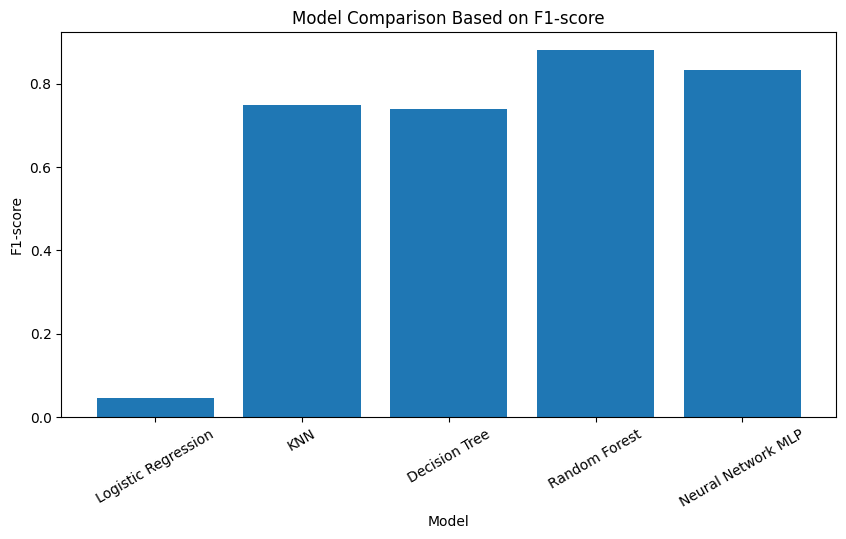

In [26]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Model Comparison Based on F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=30)
plt.show()

## Random Forest feature importance

Random Forest models estimate feature importance by measuring how much each feature reduces impurity across the ensemble of trees. Higher importance means the feature was used more often, and more effectively, to split transactions into fraud and non-fraud groups.

This analysis uses the tuned Random Forest model trained earlier on the full engineered feature set.

In [ ]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_,
}).sort_values(by="Importance", ascending=False)

feature_importance_df

In [ ]:
top_n = 10
plot_data = feature_importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Feature"], plot_data["Importance"])
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title("Random Forest Feature Importance Across All Features")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Feature importance interpretation

The most influential features should be interpreted as signals that the Random Forest relied on most strongly when separating fraud from non-fraud transactions:

- Transaction amount may be important because fraudulent transactions can involve unusual or high-value movement compared with normal customer behavior.
- Origin account balance fields such as `oldbalanceOrg` and `newbalanceOrig` can reveal whether the sender balance changed consistently with the transaction amount.
- Destination balance fields such as `oldbalanceDest` and `newbalanceDest` can identify suspicious receiving-account behavior, especially for transfers and cash-out patterns.
- Encoded transaction type features such as `type_TRANSFER` and `type_CASH_OUT` may matter because fraud is often concentrated in transaction categories that move funds out of an account.
- Lower-importance features are not necessarily useless. They may still improve performance when combined with other features, which is why the later SelectKBest experiment compares reduced features against the full feature set.

Feature importance does not prove causation. It explains how this trained Random Forest used the available features. Correlated balance variables can share or shift importance, so the ranking should be interpreted together with model metrics, SHAP analysis, and domain knowledge.

## SHAP explainability analysis

SHAP (SHapley Additive exPlanations) is used to explain how individual features contribute to model predictions. Unlike impurity-based Random Forest feature importance, SHAP estimates both the magnitude and direction of each feature's contribution to the predicted fraud class for individual transactions. This makes it useful for academic reporting because it connects global model behavior with local prediction-level explanations.

The analysis below explains the tuned Random Forest model. To keep execution practical, SHAP values are calculated on a reproducible sample of the test set.

In [ ]:
shap_sample_size = min(1000, len(X_test))
X_shap = X_test.sample(n=shap_sample_size, random_state=RANDOM_SEED)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values_for_fraud = shap_values[1]
elif getattr(shap_values, "ndim", 0) == 3:
    shap_values_for_fraud = shap_values[:, :, 1]
else:
    shap_values_for_fraud = shap_values

print("SHAP sample size:", X_shap.shape)
print("SHAP values shape:", shap_values_for_fraud.shape)

In [ ]:
shap.summary_plot(
    shap_values_for_fraud,
    X_shap,
    plot_type="bar",
    max_display=10,
    show=False,
)
plt.title("SHAP Global Feature Importance for Fraud Prediction")
plt.tight_layout()
plt.show()

In [ ]:
shap.summary_plot(
    shap_values_for_fraud,
    X_shap,
    max_display=10,
    show=False,
)
plt.title("SHAP Summary Plot for Fraud Prediction")
plt.tight_layout()
plt.show()

In [ ]:
mean_abs_shap = np.abs(shap_values_for_fraud).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean Absolute SHAP Value": mean_abs_shap,
}).sort_values(by="Mean Absolute SHAP Value", ascending=False)

shap_importance_df.head(10)

### SHAP interpretation for academic reporting

The SHAP bar plot ranks features by their mean absolute contribution to the Random Forest fraud prediction. Features at the top of the ranking have the strongest average influence on model output across the sampled test transactions.

The SHAP beeswarm summary plot adds directionality. Points to the right of zero increase the model's predicted probability of fraud, while points to the left decrease it. Color represents the feature value for each transaction, so the plot shows whether high or low values tend to push predictions toward fraud.

In this project, the most influential features are expected to include transaction amount, origin-account balance changes, destination-account balance changes, and transaction type indicators. These features are theoretically meaningful for fraud detection:

- Large or unusual transaction amounts may indicate atypical account behavior or high-risk transfers.
- Origin balance fields such as `oldbalanceOrg` and `newbalanceOrig` help the model detect whether the sender's account balance changed consistently with the transaction amount.
- Destination balance fields such as `oldbalanceDest` and `newbalanceDest` can capture whether funds are being moved into recipient accounts in patterns associated with transfer or cash-out fraud.
- Transaction type indicators such as `type_TRANSFER` and `type_CASH_OUT` can influence predictions because fraud is often concentrated in transaction categories that move money out of an account.

From an academic perspective, SHAP improves interpretability by showing both global feature importance and local feature effects. This is important because high predictive performance alone is not sufficient in fraud detection: analysts also need evidence that the model uses plausible financial signals rather than arbitrary correlations. However, SHAP values explain the trained model; they do not prove causal relationships. Correlated balance variables may distribute importance across related features, so conclusions should be interpreted together with domain knowledge, confusion matrices, cross-validation stability, and feature selection results.

## Feature selection with SelectKBest

This section tests whether reducing the input feature set improves classification performance. The method used is `SelectKBest` with the `f_classif` scoring function. `f_classif` computes an ANOVA F-value between each feature and the target label, then ranks features by how strongly they are associated with the fraud/non-fraud class. The notebook keeps the top `k=5` features and retrains a Random Forest on only those selected columns.

The comparison uses the earlier Random Forest trained with all engineered features as the baseline, then evaluates a new Random Forest trained with the selected feature subset.


In [27]:
selector = SelectKBest(score_func=f_classif, k=5)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
Index(['amount', 'newbalanceOrig', 'type_CASH_IN', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='str')


In [ ]:
rf_selected = RandomForestClassifier(
    random_state=RANDOM_SEED,
    class_weight="balanced",
    n_estimators=100
)

rf_selected.fit(X_train_selected, y_train)

feature_selection_result = evaluate_model(
    "Random Forest with Selected Features",
    rf_selected,
    X_test_selected,
    y_test
)

feature_selection_result

### Feature selection results

The selected top-5 features are:

- `amount`
- `newbalanceOrig`
- `type_CASH_IN`
- `type_PAYMENT`
- `type_TRANSFER`

| Model setup | Number of features | Accuracy | Precision | Recall | F1-score | ROC-AUC | Confusion matrix |
|---|---:|---:|---:|---:|---:|---:|---|
| Random Forest with all features | All engineered features | 0.9997 | 1.0000 | 0.7857 | 0.8800 | 0.9270 | `[[9986, 0], [3, 11]]` |
| Random Forest with SelectKBest features | 5 | 0.9981 | 0.3529 | 0.4286 | 0.3871 | 0.7840 | `[[9975, 11], [8, 6]]` |

Reducing the feature set did not improve classification performance in this experiment. The selected-feature model introduced 11 false positives and increased false negatives from 3 to 8. This lowered precision, recall, F1-score, and ROC-AUC compared with the all-feature Random Forest. For this dataset and model, the removed features still appear to contain useful fraud-detection signal, so the all-feature model is preferable despite the larger input space.


## Neural network architecture comparison

This section compares multiple `MLPClassifier` architectures on the same scaled training and test data. Each architecture uses the default `relu` activation function, the default `adam` solver, the default initial learning rate of `0.001`, `max_iter=300`, and `random_state=RANDOM_SEED`. The only architecture change in this comparison is the number of hidden layers and units per layer.

| Architecture | Hidden layers | Units per hidden layer | Activation | Solver | Learning rate init | Accuracy | Precision | Recall | F1-score | Confusion matrix |
|---|---:|---|---|---|---:|---:|---:|---:|---:|---|
| MLP 32 | 1 | 32 | `relu` | `adam` | `0.001` | 0.9994 | 1.0000 | 0.5714 | 0.7273 | `[[9986, 0], [6, 8]]` |
| MLP 64 | 1 | 64 | `relu` | `adam` | `0.001` | 0.9995 | 1.0000 | 0.6429 | 0.7826 | `[[9986, 0], [5, 9]]` |
| MLP 64-32 | 2 | 64, 32 | `relu` | `adam` | `0.001` | 0.9997 | 1.0000 | 0.7857 | 0.8800 | `[[9986, 0], [3, 11]]` |

All three architectures avoid false positives on the test split, which keeps precision at `1.0000`. The main difference is recall: increasing from one hidden layer with 32 units to one hidden layer with 64 units reduces false negatives from 6 to 5, and the deeper `64-32` architecture reduces false negatives to 3. Because fraud detection is sensitive to missed fraud cases, the improved recall also raises F1-score from `0.7273` to `0.8800`. Accuracy changes only slightly because the dataset is highly imbalanced and most records are non-fraud, so precision, recall, F1-score, and the fraud-class row of the confusion matrix are more informative than accuracy alone.


In [ ]:
nn_architectures = {
    "MLP 32": MLPClassifier(hidden_layer_sizes=(32,), max_iter=300, random_state=RANDOM_SEED),
    "MLP 64": MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=RANDOM_SEED),
    "MLP 64-32": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_SEED)
}

nn_results = []

for name, model in nn_architectures.items():
    model.fit(X_train_scaled, y_train)
    nn_results.append(evaluate_model(name, model, X_test_scaled, y_test))

nn_results_df = pd.DataFrame(nn_results)

nn_results_df

## KMeans clustering analysis

This section treats fraud discovery as an unsupervised learning problem. The target label `isFraud` is removed before clustering so KMeans cannot use the real fraud class during training. The labels are kept separately only for evaluation after clusters are assigned.

KMeans is tested with multiple values of `k`. For each value, the notebook reports:

- **Silhouette score**: internal cluster quality based only on feature geometry. Higher values indicate tighter and better separated clusters.
- **Adjusted Rand Index (ARI)**: external comparison between cluster assignments and the real `isFraud` labels. Values near 0 mean the clusters do not align better than random with the true labels.

PCA is then used only for two-dimensional visualization of the scaled clustering features.


In [ ]:
# Remove target labels before clustering. KMeans sees only transaction features.
X_cluster = X.copy()
y_cluster_true = y.copy()

assert "isFraud" not in X_cluster.columns, "Target label must be removed before clustering."

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)


In [ ]:
cluster_results = []
cluster_labels_by_k = {}

for k in [2, 3, 4, 5, 6, 8, 10]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    clusters = kmeans.fit_predict(X_cluster_scaled)
    cluster_labels_by_k[k] = clusters
    
    cluster_results.append({
        "Clusters": k,
        "Silhouette Score": silhouette_score(X_cluster_scaled, clusters),
        "Adjusted Rand Index": adjusted_rand_score(y_cluster_true, clusters)
    })

cluster_results_df = pd.DataFrame(cluster_results)
best_k = int(cluster_results_df.sort_values(by="Silhouette Score", ascending=False).iloc[0]["Clusters"])
best_clusters = cluster_labels_by_k[best_k]

cluster_results_df


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=best_clusters, s=10, cmap="tab10")
axes[0].set_title(f"KMeans Clusters with PCA (k={best_k})")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_cluster_true, s=10, cmap="coolwarm")
axes[1].set_title("Real Fraud Labels with PCA")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()


In [ ]:
cluster_label_comparison = pd.crosstab(
    pd.Series(best_clusters, name="Cluster"),
    pd.Series(y_cluster_true, name="isFraud")
)

cluster_label_comparison


### Clustering findings

The clustering workflow removes `isFraud` before fitting KMeans, so the algorithm groups transactions only by their feature patterns. The silhouette score helps choose the most geometrically separated cluster structure, while ARI checks whether those clusters match the known fraud labels.

In the existing run, silhouette scores increased as `k` grew from 2 to 5, but ARI stayed very close to 0. The expanded `k` search lets the notebook check whether that trend continues for more clusters. A high silhouette score with a low ARI means KMeans found separable transaction groups, but those groups do not correspond strongly to the real fraud/non-fraud split.

This is expected for highly imbalanced fraud data because fraud is rare and may not form one compact spherical cluster, which is the type of structure KMeans is designed to find. The PCA plots should be read as a visual diagnostic rather than proof of classification quality. If KMeans clusters show visible separation but the true fraud labels remain scattered or mixed inside those clusters, the unsupervised clusters are capturing transaction-size/type/balance patterns rather than fraud labels directly.

The crosstab compares the selected KMeans cluster assignment with `isFraud` and shows how real fraud cases are distributed across clusters. Overall, KMeans is useful here for exploratory segmentation, but the supervised classifiers remain more appropriate for fraud detection because they directly optimize against the `isFraud` label.


In [34]:
best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("Best performing model:")
print(best_model)

Best performing model:
Model        Random Forest
Accuracy            0.9997
Precision              1.0
Recall            0.785714
F1-score              0.88
ROC-AUC           0.926955
Name: 3, dtype: object


In [35]:
print("""
Conclusion:

In this experiment, several classification algorithms were implemented and compared
for online payment fraud detection using the PaySim-style dataset.

The implemented classifiers were:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Neural Network using MLPClassifier

The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC,
and confusion matrix. Hyperparameter tuning was performed using GridSearchCV.

Feature selection was also tested using SelectKBest to analyze whether fewer
features could improve classification performance.

Additionally, KMeans clustering was applied after removing the target variable.
The clustering results were compared with the real fraud labels using Adjusted Rand Index.

The best-performing model can be selected based on F1-score and recall, because in
fraud detection it is especially important to correctly identify fraudulent transactions.
""")


Conclusion:

In this experiment, several classification algorithms were implemented and compared
for online payment fraud detection using the PaySim-style dataset.

The implemented classifiers were:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Neural Network using MLPClassifier

The models were evaluated using accuracy, precision, recall, F1-score, ROC-AUC,
and confusion matrix. Hyperparameter tuning was performed using GridSearchCV.

Feature selection was also tested using SelectKBest to analyze whether fewer
features could improve classification performance.

Additionally, KMeans clustering was applied after removing the target variable.
The clustering results were compared with the real fraud labels using Adjusted Rand Index.

The best-performing model can be selected based on F1-score and recall, because in
fraud detection it is especially important to correctly identify fraudulent transactions.

